In [55]:
import numpy as np
import pandas as pd
import os, os.path,sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import scipy
import plotly.express as px
import plotly.graph_objects as go


In [56]:
def montecarlo_stuff(static_val,ppf_val=0.7):
    static_val = static_val.clip(min=0)
                    
            # # Save results of the test model with validation dataset 
            


    dist_load_forecasted = scipy.stats.norm(loc=static_val.mean(axis=-1),
                                        scale=static_val.std(axis=-1))


    # upper_load_forecasted = dist_load_forecasted.ppf(0.7) 
    upper_load_forecasted = dist_load_forecasted.ppf(ppf_val) 

    upper_load_forecasted[np.where(np.isnan(upper_load_forecasted))] = (
    static_val[np.where(np.isnan(upper_load_forecasted))][:, 0])
    return upper_load_forecasted

In [57]:
def load_scalers(city, ppf_static, ppf_helper,delay,phi,eta):
    ''' Load the scalers for the static and shared data.'''
   
    static_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/block_1_minmaxscaler.pkl'), 'rb'))
    shared_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/block_2_minmaxscaler.pkl'), 'rb'))
    return static_scaler, shared_scaler


def denormalize_normalize_static_shared(static,shared, static_scaler,shared_scaler, mae_forecasting, real_data, test_index_start):
    ''' Denormalize the static data using the scaler. '''
    static_denorm = static_scaler.inverse_transform(static) # Static = block 1
    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared, axis=-1)) # Shared = block 2
    mae_denorm = np.zeros(mae_forecasting.shape) # MAE = helper
    for i in range(B):
        mae_denorm[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm / 10e9 # Shared = block 2
    static_norm = static_denorm / 10e9 # Static = block 1
    mae_norm = mae_denorm / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data

    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff

    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

    return static_norm, shared_norm, mae_norm, output_norm


def upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper,multiple=False):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')

    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    ppf_2_static = .999
    ppf_2_helper = .999

    upper_cd_static = dist_cd.ppf(ppf_2_static) # Can be changed. If set to 0.5 = mean
    upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
        cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
    upper_cs_shared = dist_cs.ppf(ppf_2_helper) # Can be changed. If set to 0.5 = mean 
    upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
        cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

    if multiple:
        return cap_static, cap_shared
    else:
        return upper_cd_static, upper_cs_shared

def load_mae_forecasting(city,static_scaler):
    mae_forecasting = np.transpose(np.load(os.path.join(ROOT_DIR,f'./{results_path}/{city}/helper_forecasting_delay_1.npy')), (0,2,1))
    
    return mae_forecasting

def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

In [58]:
# ROOT_DIR = ''
ROOT_DIR ='/home/sergi_alcala/sergi_data/AZTEC_extension/'
print(f'Root dir: {ROOT_DIR}')

Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension/


In [59]:
def fun_total_cost(output_norm,cplus,static_norm,shared_norm,city_df,alpha,num_services,phi,eta):

    gamma = 2 # positive slope always fix
    
    cplus_denorm = cplus * 10e9 
    static_denorm = static_norm * 10e9
    shared_denorm = shared_norm * 10e9
    output_denorm = output_norm * 10e9

    # print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

    test_length=min(len(output_norm),len(shared_norm))
    # 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
    # It may change city by city
    #test_length = 1734

    delta_i = np.zeros((test_length, num_services)) 
    rho_i = np.zeros((test_length, num_services))

    indexes_under = np.where((static_denorm[:test_length] - output_denorm[:test_length]) > 0)
    indexes_above = np.where((static_denorm[:test_length] - output_denorm[:test_length]) < 0)

    # Where the real load is below the allocated static, delta_i is equal to the real load.
    # In this case rho_i is equal to 0.

    for idx, element in enumerate(indexes_under[0]):
        delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

    # Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
    # In this case rho_i is equal to the difference between real load and static allocated.
        
    for idx, element in enumerate(indexes_above[0]):
        delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx]]
        rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                                - static_denorm[element, indexes_above[1][idx]])
        
    cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                                - output_denorm[:test_length]).sum() * gamma

    # Amount of capacity overprovisioned, i.e. higher than real output

    overprovisioning = (static_denorm[:test_length]
                        + cplus_denorm.T[:test_length] - output_denorm[:test_length]).clip(min=0)

    # Cost of the overprovisioning.
    # It includes the leftover shared capacity that have been provided by block 2 but not used by block 3.
    # The total cost is normalized by the total real load.
    # cost_overprovisioning = ((overprovisioning.sum()
    #                         + (shared_denorm[:test_length] - cplus_denorm.T[:test_length]).clip(min=0).sum())
    #                         * gamma / cost_normalization_factor)
    


    cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services

    cost_overprovisioning = ((overprovisioning.sum()
                            + (shared_denorm[:test_length] -cplus_all).clip(min=0).sum())
                            * gamma / cost_normalization_factor)
    
    cost_overprovisioning_static = (overprovisioning.sum() * gamma / cost_normalization_factor)
    cost_overprovisioning_shared = ((shared_denorm[:test_length] -cplus_all).clip(min=0).sum()
                            * gamma / cost_normalization_factor)

    slas = np.zeros((test_length, num_services))

    # Where the shared allocated is below rho_i it means that the real load is higher than the total capacity, i.e., slas violation

    slas[np.where((cplus_denorm.T[:test_length] - rho_i) < 0)] += 1

    # The cost of slas is equal to the total number of slas per app multiplied by the max load value of each app multiplied by alpha.

    # The cost is then normalized as for the overprovisioning.
    max_concatenated= city_df.max(axis=0)

    cost_slas = (slas.sum(axis=0) * alpha * max_concatenated / cost_normalization_factor).sum()


    # eta = 2 # cost of instantiation

    delta_static = static_denorm[:test_length] - np.roll(static_denorm[:test_length], 1,axis=0)
    delta_static[0] = static_denorm[0]
    delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis=0)
    delta_shared[0] = cplus_denorm.T[0]

    cost_instantiation_static = np.zeros((test_length, num_services))
    cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

    cost_instantiation_shared = np.zeros((test_length, num_services))

    cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

    cost_instantiation = (cost_instantiation_static.sum()
                        + cost_instantiation_shared.sum()) / cost_normalization_factor

    reconfiguration = np.zeros((test_length, num_services))
    reconfiguration[np.where(delta_shared != 0)] = phi * rho_i[np.where(delta_shared != 0)]

    cost_reconfiguration = reconfiguration.sum() / cost_normalization_factor

    total_cost = cost_overprovisioning + cost_slas + cost_instantiation + cost_reconfiguration

    return total_cost, cost_overprovisioning , cost_slas , cost_instantiation , cost_reconfiguration,slas.sum(axis=0),cost_overprovisioning_static, cost_overprovisioning_shared

In [60]:
def select_cplus_np(cplus_df):
    cplus_df_sel=cplus_df.iloc[:,5:10]
    cplus_df_sel_np=cplus_df_sel.T.to_numpy()
    return cplus_df_sel_np

In [61]:
def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start

In [62]:
def Confidence_Interval(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')

    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    #compute confidence interval

    mean_cd_static = dist_cd.mean()
    mean_cs_shared = dist_cs.mean()
    std_cd_static = dist_cd.std()
    std_cs_shared = dist_cs.std()
    #confidence interval
    z = 1.96 # 95% confidence interval
    upper_cd_static = mean_cd_static + z * std_cd_static
    lower_cd_static = mean_cd_static - z * std_cd_static
    upper_cs_shared = mean_cs_shared + z * std_cs_shared
    lower_cs_shared = mean_cs_shared - z * std_cs_shared
    #print(f'upper_cd_static: {upper_cd_static}, lower_cd_static: {lower_cd_static}, upper_cs_shared: {upper_cs_shared}, lower_cs_shared: {lower_cs_shared}')
    #print(f'upper_cd_static: {upper_cd_static}, lower_cd_static: {lower_cd_static}, upper_cs_shared: {upper_cs_shared}, lower_cs_shared: {lower_cs_shared}')

    return upper_cd_static, lower_cd_static, upper_cs_shared, lower_cs_shared

def extract_dist(city,ppf_helper,ppf_static,phi,eta,alpha,delay,results_path,save_raw_data=False):
    csv_path=f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'
    # print(csv_path)
    
    # if os.path.exists(csv_path):
    test_index_start=fun_test_index_start(city,delay)
    
    cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
    cplus_df_sel_np=select_cplus_np(cplus_df)
    
    
    upper_cd_static, lower_cd_static, upper_cs_shared, lower_cs_shared=Confidence_Interval(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)

    return upper_cd_static, lower_cd_static, upper_cs_shared, lower_cs_shared
    

In [63]:
def cost_slas_analysis_CI(city,ppf_helper,ppf_static,phi,eta,alpha,delay,results_path,save_raw_data=False,upper_bound=False,lower_bound=False):

        if upper_bound:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}_UPPER_BOUND.csv'
        elif lower_bound:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}_LOWER_BOUND.csv'
        else:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'

        # print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}')
        csv_path= path
        print(csv_path)
        
        if os.path.exists(csv_path):
                test_index_start=fun_test_index_start(city,delay)
                cplus_df=pd.read_csv(csv_path)
                
                # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                cplus_df_sel_np=select_cplus_np(cplus_df)
                
                static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi,eta)
                real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
                static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                

                # length=min(static_norm.shape[0],shared_norm.shape[0],output_norm.shape[0])
                # print(f'static_norm.shape: {static_norm.shape}, shared_norm.shape: {shared_norm.shape}, output_norm.shape: {output_norm.shape},mae_norm_shape: {mae_norm.shape}')
                # print(length)
                total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas ,cost_overprovisioning_static, cost_overprovisioning_shared = fun_total_cost(output_norm,cplus_df_sel_np,static_norm,shared_norm,real_data,alpha,num_services,phi,eta)
                
                if save_raw_data:
                        if not os.path.exists(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}'):
                                os.makedirs(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}')
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy',static_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy',shared_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/mae_norm.npy',mae_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy',output_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy',slas)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy',cost_overprovisioning_static)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy',cost_overprovisioning_shared)
                        #print(f'Total cost: {total_costs}, SLAS: {slas_sum} for city {city} with ppf_static {ppf_static} and ppf_helper {ppf_helper} amd phi {phi} and alpha {alpha}')
        else:
                total_cost=np.nan
                cost_slas=np.ones(num_services)*np.nan
                cost_overprovisioning=np.nan
                cost_instantiation=np.nan
                cost_reconfiguration=np.nan
                slas=[np.nan,np.nan,np.nan,np.nan,np.nan]
                
                
                #print('File not exist')
        return total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas,static,shared


In [64]:
def cost_slas_analysis(city,ppf_helper,ppf_static,phi,eta,alpha,delay,results_path,save_raw_data=False,upper_bound=False,lower_bound=False):

        if upper_bound:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}_UPPER_BOUND.csv'
        elif lower_bound:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}_LOWER_BOUND.csv'
        else:
                path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'

        # print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}')
        csv_path= path
        print(csv_path)
        
        if os.path.exists(csv_path):
                test_index_start=fun_test_index_start(city,delay)
                cplus_df=pd.read_csv(csv_path)
                
                # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                cplus_df_sel_np=select_cplus_np(cplus_df)
                
                static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi,eta)
                real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
                static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                

                # length=min(static_norm.shape[0],shared_norm.shape[0],output_norm.shape[0])
                # print(f'static_norm.shape: {static_norm.shape}, shared_norm.shape: {shared_norm.shape}, output_norm.shape: {output_norm.shape},mae_norm_shape: {mae_norm.shape}')
                # print(length)
                total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas ,cost_overprovisioning_static, cost_overprovisioning_shared = fun_total_cost(output_norm,cplus_df_sel_np,static_norm,shared_norm,real_data,alpha,num_services,phi,eta)
                
                if save_raw_data:
                        if not os.path.exists(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}'):
                                os.makedirs(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}')
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/static_norm.npy',static_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/shared_norm.npy',shared_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/mae_norm.npy',mae_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/output_norm.npy',output_norm)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/slas.npy',slas)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_static.npy',cost_overprovisioning_static)
                        np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy',cost_overprovisioning_shared)
                        #print(f'Total cost: {total_costs}, SLAS: {slas_sum} for city {city} with ppf_static {ppf_static} and ppf_helper {ppf_helper} amd phi {phi} and alpha {alpha}')
        else:
                total_cost=np.nan
                cost_slas=np.ones(num_services)*np.nan
                cost_overprovisioning=np.nan
                cost_instantiation=np.nan
                cost_reconfiguration=np.nan
                slas=[np.nan,np.nan,np.nan,np.nan,np.nan]
                
                
                #print('File not exist')
        return total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas,static,shared


In [65]:
### Skip warnings
import warnings
warnings.filterwarnings("ignore")

In [66]:
def df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list):
    df_costs=pd.DataFrame({'total_costs':total_costs_list,'cost_overprovisioning':cost_overprovisioning_list,'cost_slas':cost_slas_list,'cost_instantiation':cost_instantiation_list,'cost_reconfiguration':cost_reconfiguration_list},index=sla_perc_list_index_list)
    return df_costs

In [67]:
import scipy.stats as stats

In [68]:
confidence_level = 0.95

In [14]:
z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)

In [15]:
z_score

1.959963984540054

In [73]:

LOOKBACK = 6 # History given as input to the network. Could be modified if needed

gamma = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper

#B = 100 # Number of montecarlo output

#ppf_helper = 0.75 # Percentile of the helper
#ppf_static = 0.1 # Percentile of the static model
lookback = 6
num_services = 5
#delay = 6
B = 100

ppf_helper_list=[0.7]
ppf_static_list=[0.9]

# ppf_helper_list=[0.7]
# ppf_static_list=[0.9,0.99]

# ppf_helper_list=[0.6,0.65,0.7,.75,0.9,0.99]
# ppf_helper_list=[0.75]
# ppf_helper_list=[0.5,0.55,0.6,0.65]

# ppf_helper_list=[0.99]
# ppf_static_list=[0.6,0.65,0.7,.75,0.9,0.99]



# ppf_helper_list=[0.75] ##### AZTEC PAPER PPF's
# ppf_static_list=[0.1,0.5] ##### AZTEC PAPER PPF's

SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
# PHIS = [0.1,0.5,1,10] # Negative slope of the loss function TO BE MODIFIED 
PHIS=[0.1,0.5,1,10]
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
#         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']

cities = ['Paris']
ETAS =[1,2,10,20,30,40,50,70,90,100]
# ETAS = [1,2]

# ALPHAS=[2,3,5]
ALPHAS=[2]

# TB_Fpath=f'Training_block_new_mean_tesT_'
# results_path='results_new_mean_test_'

# TB_Fpath = 'TEST_4_H'
# TB_Fpath = 'Training_FIX_INSTANTATION'
# results_path = 'results_mix_match'

# results_path = 'Results_100_sim'
# results_path = 'Results_100_sim_bounds_2_100'
# results_path = 'results_TEST_4_H_mean'
# results_path = 'results_TEST_4_H_mean'
# results_path = 'Results_AZTEC_6'
# results_path = 'Results_Pipeline'
#ALPHAS=[0.75]


# TB_Fpath = 'Training_FIX_INSTANTATION'
# results_path = 'Results_INSTANTATION_FIX'
results_path = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed'
# results_path = 'Results_Optimal_Cities_denorm'
# sergi_data/AZTEC_extension/




# ppf_static_list=[0.9]
# ppf_helper_list=[0.6,0.65,0.7,.75,0.9,0.99]
# # ppf_helper_list=[0.75]
# # ppf_helper_list=[0.5,0.55,0.6,0.65]

# # ppf_helper_list=[0.99]
# ppf_static_list=[0.6,0.65,0.7,.75,0.9,0.99]


total_costs_list=[]
cost_overprovisioning_list=[]
cost_slas_list=[]
cost_instantiation_list=[]
cost_reconfiguration_list=[]

bound = 'none' ## 'upper' or 'lower' or 'none'

if bound == 'upper':
    upper_bound=True
    lower_bound=False
    save_path = 'Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05_UPPER_BOUND.csv'
elif bound == 'lower':
    upper_bound=False
    lower_bound=True
    save_path = 'Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05_LOWER_BOUND.csv'
else:
    upper_bound=False
    lower_bound=False
    save_path = 'Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05.csv'


save_raw_data=False
cost_instantiation_list_ = np.zeros((len(PHIS),len(ETAS)))
sla_perc_list_index_list=[]
slas_count_list=[]
for city in cities:
    for ppf_helper in (ppf_helper_list):
        for ppf_static in (ppf_static_list):
            for i,phi in enumerate(PHIS):
                for j, eta in enumerate(ETAS):
                    for alpha in (ALPHAS):
                        
                        
                        if results_path=='Results_old':
                            delay=6
                        elif results_path=='Results_AZTEC_6':
                            delay=5
                        else:
                            delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
                        # print(f' Delay {delay}')
                        total_cost, cost_overprovisioning ,cost_slas , cost_instantiation , cost_reconfiguration,slas,static,shared=cost_slas_analysis(
                            city,ppf_helper,ppf_static,phi,eta,alpha,delay,results_path,save_raw_data,upper_bound,lower_bound)
                        total_costs_list.append(total_cost)
                        cost_slas_list.append(cost_slas)
                        cost_overprovisioning_list.append(cost_overprovisioning)
                        cost_instantiation_list.append(cost_instantiation)
                        cost_reconfiguration_list.append(cost_reconfiguration)
                        sla_perc_list_index=f'{city}_ppf_static_{ppf_static}_ppf_helper_{ppf_helper}_phi_{phi}_eta_{eta}_alpha_{alpha}_delay_{delay}'
                        sla_perc_list_index_list.append(sla_perc_list_index)
                        slas_count_list.append(slas)
                        cost_instantiation_list_[i,j]=cost_instantiation

                    

/home/sergi_alcala/sergi_data/AZTEC_extension//Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_1/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_21/Block_3_shared_cplus_sla_delay_21_phi_0.1_alpha2_gamma_2.csv
/home/sergi_alcala/sergi_data/AZTEC_extension//Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_2/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_27/Block_3_shared_cplus_sla_delay_27_phi_0.1_alpha2_gamma_2.csv
/home/sergi_alcala/sergi_data/AZTEC_extension//Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_10/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_35/Block_3_shared_cplus_sla_delay_35_phi_0.1_alpha2_gamma_2.csv
/home/sergi_alcala/sergi_data/AZTEC_extension//Results_Optimal_Cities_test_kr_ki_ALLOC_changed/Paris/PHI_0.1/ETA_20/Block_2_3_results/ppf_static_0.9_ppf_helper_0.7/Th_85/Block_3_shared_cplus_sla_delay_85_phi_0.1_alpha2_gamma_2.csv
/home/sergi_alcala/sergi_data/AZTEC_extension//Results_Optimal_Cities_test_kr_

In [37]:
shared[0]

0.0004726195502936375

In [ ]:
def compute_instantiation_costs_per_item( static,shared,mae,cplus,real_data, test_index_start):
    #### DENORMALIZATION ###
    cost_instantiation_list=[]
    static_denorm_100 = np.zeros((static.shape))
    shared_denorm_100 = np.zeros((shared.shape))
    for i in range(B):
        static_denorm = static_scaler.inverse_transform(static[:,:,i]) # Static = block 1
        static_denorm_100[:,:,i]=static_denorm

        shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared[:,i], axis=-1)) # Shared = block 2
        shared_denorm_100[:,i]=shared_denorm.reshape(-1)

        mae_forecasting[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm_100 / 10e9 # Shared = block 2
    static_norm = static_denorm_100 / 10e9 # Static = block 1
    mae_norm = mae_forecasting / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data

    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff

    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

### COST COMPUTATION###

    gamma = 2 # positive slope always fix

    cplus_denorm = cplus_df_sel_np * 10e9 
    static_denorm = static_norm * 10e9
    shared_denorm = shared_norm * 10e9
    output_denorm = output_norm * 10e9

    # print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

    test_length=min(len(output_norm),len(shared_norm))
    # 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
    # It may change city by city
    #test_length = 1734

    cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services




    cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                                    - output_denorm[:test_length]).sum() * gamma

    # eta = 2 # cost of instantiation
    
    for i in range(B):


        delta_i = np.zeros((test_length, num_services)) 
        rho_i = np.zeros((test_length, num_services))

        indexes_under = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) > 0)
        indexes_above = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) < 0)

        # Where the real load is below the allocated static, delta_i is equal to the real load.
        # In this case rho_i is equal to 0.

        for idx, element in enumerate(indexes_under[0]):
            delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

        # Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
        # In this case rho_i is equal to the difference between real load and static allocated.

        for idx, element in enumerate(indexes_above[0]):
            delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx],i]
            rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                                - static_denorm[element, indexes_above[1][idx],i])

        delta_static = static_denorm[:test_length,:,i] - np.roll(static_denorm[:test_length,:,i], 1,axis=0)
        delta_static[0] = static_denorm[0,:,i]
        delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis=0)
        delta_shared[0] = cplus_denorm.T[0]

        cost_instantiation_static = np.zeros((test_length, num_services))
        cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

        cost_instantiation_shared = np.zeros((test_length, num_services))

        cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

        cost_instantiation = (cost_instantiation_static.sum()
                            + cost_instantiation_shared.sum()) / cost_normalization_factor
        cost_instantiation_list.append(cost_instantiation)

    return np.array(cost_instantiation_list)




In [47]:

LOOKBACK = 6 # History given as input to the network. Could be modified if needed

gamma = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper

#B = 100 # Number of montecarlo output

#ppf_helper = 0.75 # Percentile of the helper
#ppf_static = 0.1 # Percentile of the static model
lookback = 6
num_services = 5
#delay = 6
B = 100

ppf_helper_list=[0.7]
ppf_static_list=[0.9]

# ppf_helper_list=[0.7]
# ppf_static_list=[0.9,0.99]

# ppf_helper_list=[0.6,0.65,0.7,.75,0.9,0.99]
# ppf_helper_list=[0.75]
# ppf_helper_list=[0.5,0.55,0.6,0.65]

# ppf_helper_list=[0.99]
# ppf_static_list=[0.6,0.65,0.7,.75,0.9,0.99]



# ppf_helper_list=[0.75] ##### AZTEC PAPER PPF's
# ppf_static_list=[0.1,0.5] ##### AZTEC PAPER PPF's

SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
PHIS = [0.1,0.5,1,10] # Negative slope of the loss function TO BE MODIFIED 
# PHIS=[0.1]
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
#         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']

cities = ['Paris']
ETAS =[1,2,10,20,30,40,50,70,90,100]
# ETAS = [1]
ALPHAS=[2]




results_path = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed'

total_costs_list=[]
cost_overprovisioning_list=[]
cost_slas_list=[]
cost_instantiation_list=[]
cost_reconfiguration_list=[]

instantiation_costs = np.zeros((len(PHIS),len(ETAS),B))

save_raw_data=False

sla_perc_list_index_list=[]
slas_count_list=[]
for city in cities:
    for ppf_helper in (ppf_helper_list):
        for ppf_static in (ppf_static_list):
            for i,phi in enumerate(PHIS):
                for j,eta in enumerate(ETAS):
                    for alpha in (ALPHAS):
                        
                        
                        if results_path=='Results_old':
                            delay=6
                        elif results_path=='Results_AZTEC_6':
                            delay=5
                        else:
                            delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
                        # print(f' Delay {delay}')
                        # upper_cd_static, lower_cd_static, upper_cs_shared, lower_cs_shared=extract_dist(city,ppf_helper,ppf_static,phi,eta,alpha,delay,results_path,save_raw_data)
                        # cap_static = np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
                        # cap_shared=np.load(os.path.join(ROOT_DIR,f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
                        test_index_start=fun_test_index_start(city,delay)
                        csv_path = path= f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv'
                        cplus_df=pd.read_csv(csv_path)
                        
                        # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                        # cplus_df=pd.read_csv(f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_{gamma}.csv')
                        cplus_df_sel_np=select_cplus_np(cplus_df)
                        
                        static_scaler, shared_scaler = load_scalers(city, ppf_static, ppf_helper,delay,phi,eta)
                        real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city,static_scaler)
                        static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                        # static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                        cost_instantiation = compute_instantiation_costs_per_item(static,shared,mae_forecasting,cplus_df_sel_np,real_data,test_index_start)
                        
                        instantiation_costs[i,j,:] = cost_instantiation
                        
                

                    

In [80]:
def compute_confidence_interval(instantiation_costs):
    # Calculate the mean and standard deviation of the instantiation costs
    mean_cd_static = np.mean(instantiation_costs, axis=0)
    std_cd_static = np.std(instantiation_costs, axis=0)
    
    # Calculate the confidence interval
    z = 2  # for 95% confidence interval
    upper_cd_static = mean_cd_static + z * std_cd_static
    lower_cd_static = mean_cd_static - z * std_cd_static
    
    return upper_cd_static, lower_cd_static

In [82]:
def obtain_std(instantiation_costs):
    # Calculate the mean and standard deviation of the instantiation costs
    mean_cd_static = np.mean(instantiation_costs, axis=0)
    std_cd_static = np.std(instantiation_costs, axis=0)
    
    return mean_cd_static, std_cd_static

In [86]:
std_list

[0.01811143780797019,
 0.03639983758088515,
 0.061633377454424966,
 0.12104543979446451,
 0.18181627931245373,
 0.24458572568764197,
 0.30371375510964416,
 0.15098984315847425,
 0.16772306969535108,
 0.18749033492414094]

In [96]:
aaa= np.std(instantiation_costs[0,-1,:])

In [97]:
aaa

0.061510407807288905

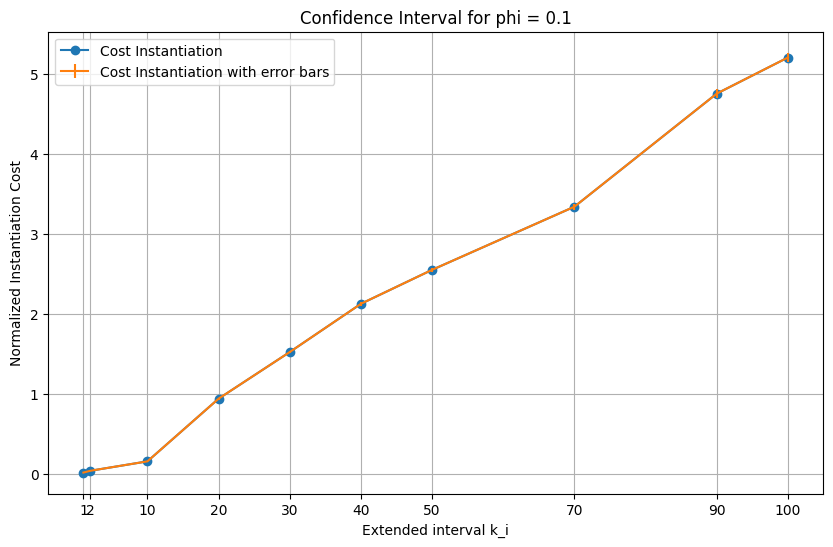

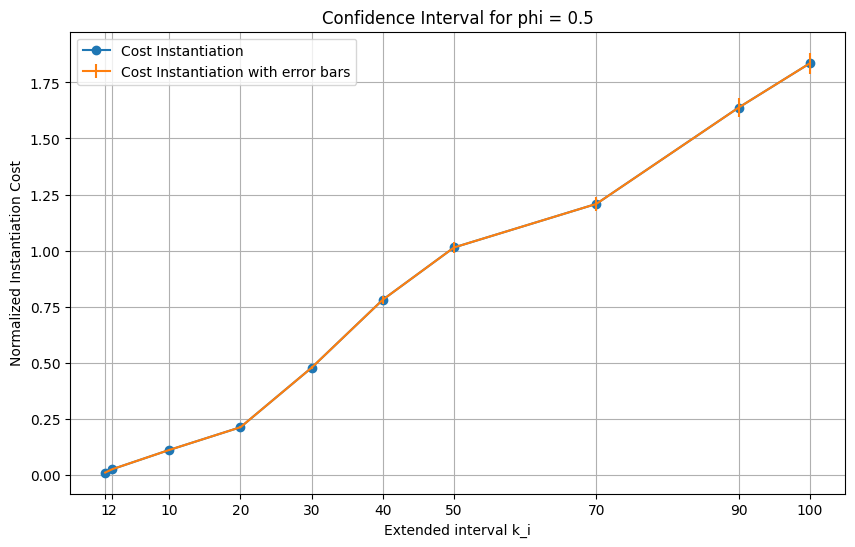

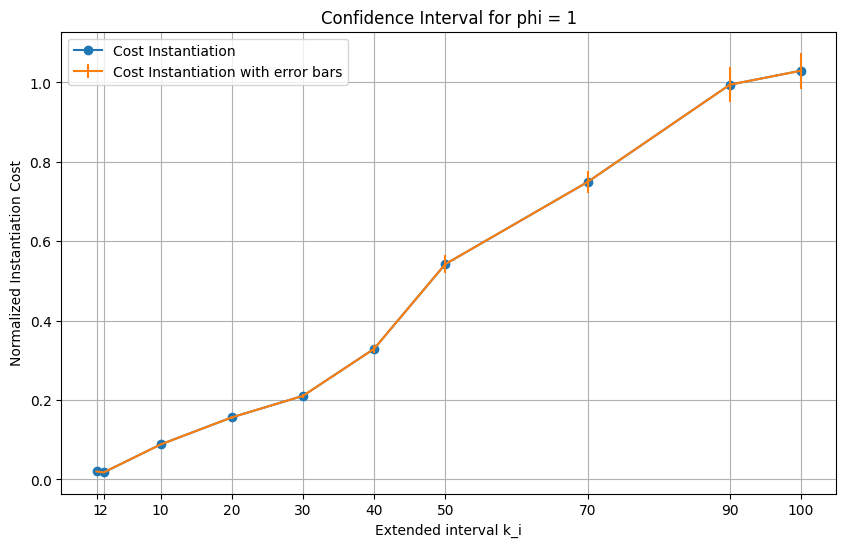

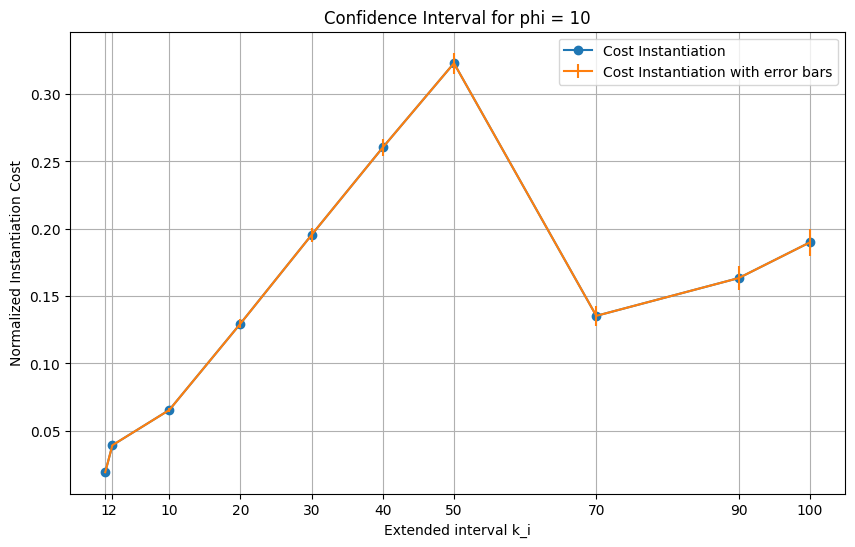

In [112]:
std_list = np.zeros((len(PHIS),len(ETAS)))
for i,phi in enumerate(PHIS):
    for j,eta in enumerate(ETAS):
        mean_cd_static, std_cd_static = obtain_std(instantiation_costs[i,j,:])
        std_list[i,j] = std_cd_static


    plt.figure(figsize=(10, 6))
  
    # plt.plot(ETAS,cost_instantiation_list_[i,:]-std_list[i], label='Cost Instantiation_lower', marker='o')
    plt.plot(ETAS,cost_instantiation_list_[i,:], label='Cost Instantiation', marker='o')
    # plt.plot(ETAS,cost_instantiation_list_[i,:]+std_list[i], label='Cost Instantiation_upper', marker='o')


    ### add the std as error bars
    plt.errorbar(ETAS, cost_instantiation_list_[i,:], yerr=[std_list[i],std_list[i]],  label='Cost Instantiation with error bars')
    # plt.fill_between(ETAS, cost_instantiation_list_[i,:]-std_list[i], cost_instantiation_list_[i,:]+std_list[i], alpha=0.2)

    plt.title(f'Confidence Interval for phi = {phi}')
    plt.xlabel(r'Extended interval k_i')
    plt.ylabel('Normalized Instantiation Cost')
    plt.xticks(ETAS)
    plt.grid()
    plt.legend()

In [113]:
np.save('std_instantiation_costs.npy',std_list)

In [90]:
std_static_list.shape

(4, 10)

In [ ]:
for i,phi in enumerate(PHIS):
   
    for j,eta in enumerate(ETAS):

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(ETAS,cost_instantiation_list_[i,:], label='Cost Instantiation', marker='o')
plt.plot(ETAS,cost_instantiation_list_[i,:]-std_list, label='lower', marker='o')
plt.plot(ETAS,cost_instantiation_list_[i,:]+std_list, label='upper', marker='o')
plt.title(f'Cost Instantiation for phi = {phi}')
plt.legend()

In [ ]:
np.save(f'{results_path}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/raw_data_{results_path}_alpha_{alpha}/cost_overprovisioning_shared.npy',cost_overprovisioning_shared)

In [75]:
cost_instantiation_list_[0]

array([0.01628736, 0.03895673, 0.15634482, 0.94019292, 1.52333128,
       2.12629524, 2.55107304, 3.34075466, 4.75467633, 5.2060232 ])

In [ ]:
cost_instantiation_list_

phi: 0.1, eta: 1, upper_cd_static: 0.02566430402238026, lower_cd_static: 0.024567622266440572
phi: 0.1, eta: 2, upper_cd_static: 0.06034950957541337, lower_cd_static: 0.05802457236454576
phi: 0.1, eta: 10, upper_cd_static: 0.25540536494097454, lower_cd_static: 0.24338045795671157
phi: 0.1, eta: 20, upper_cd_static: 1.221405265001926, lower_cd_static: 1.1683222119657648
phi: 0.1, eta: 30, upper_cd_static: 1.9330935443117268, lower_cd_static: 1.8626969647649068
phi: 0.1, eta: 40, upper_cd_static: 2.63888382284265, lower_cd_static: 2.540407767940624
phi: 0.1, eta: 50, upper_cd_static: 3.1538007524797953, lower_cd_static: 3.0476084430910664
phi: 0.1, eta: 70, upper_cd_static: 4.2527401930892195, lower_cd_static: 4.104425299151274
phi: 0.1, eta: 90, upper_cd_static: 5.870362367404896, lower_cd_static: 5.6517226028748535
phi: 0.1, eta: 100, upper_cd_static: 6.426195717473683, lower_cd_static: 6.180154086244527
phi: 0.5, eta: 1, upper_cd_static: 0.014971722838900697, lower_cd_static: 0.014228

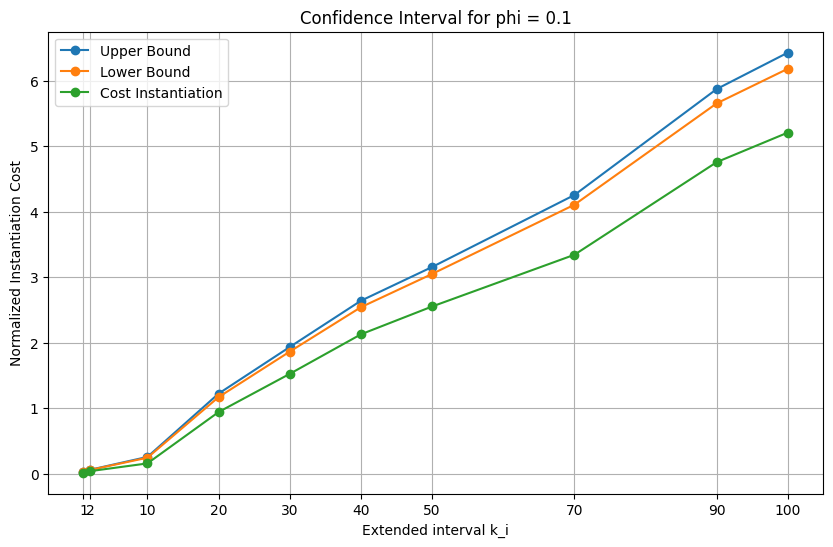

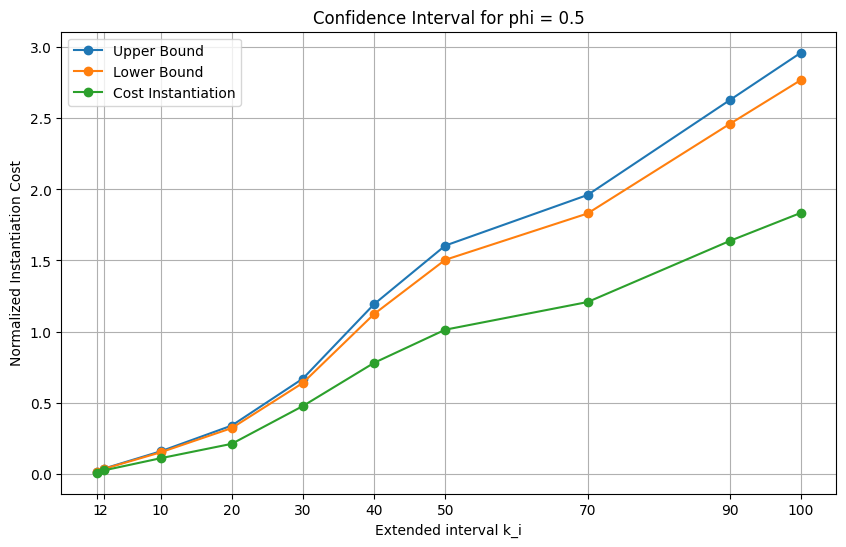

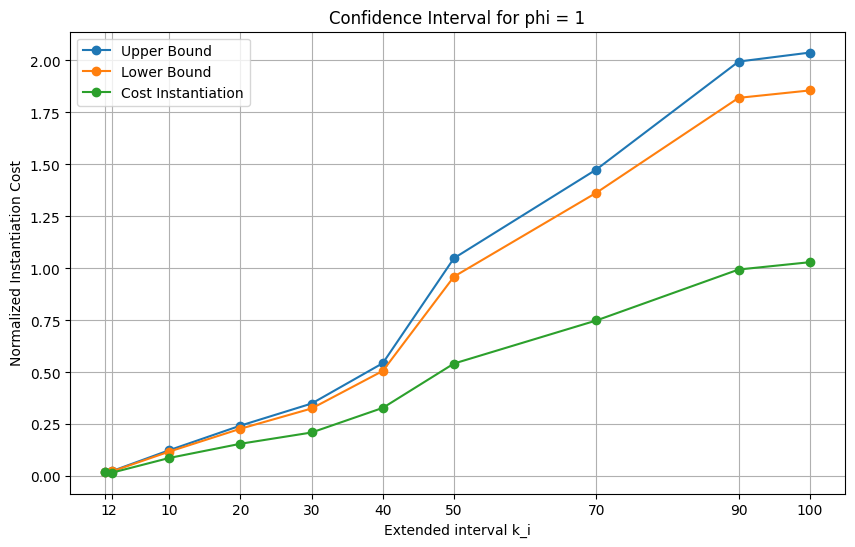

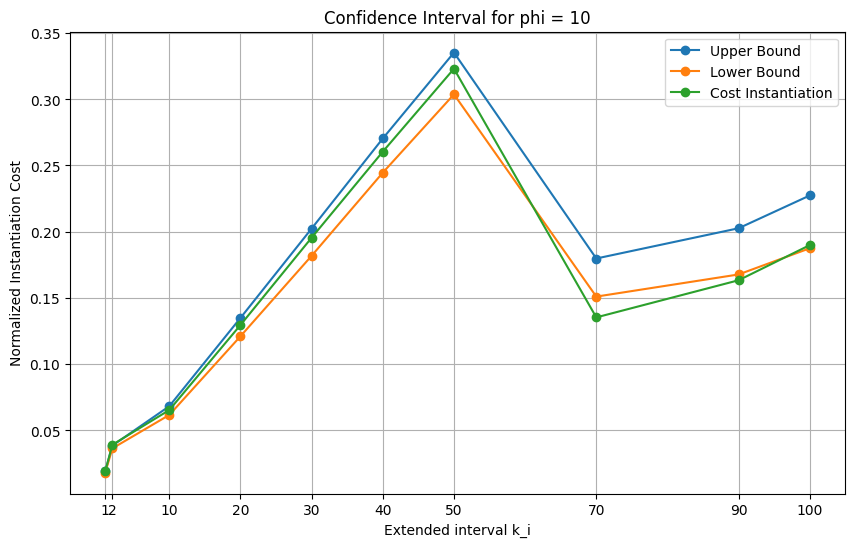

In [81]:
cost_instantiation_list_
for i,phi in enumerate(PHIS):
    upper_list = []
    lower_list = []
    for j,eta in enumerate(ETAS):
        upper_cd_static, lower_cd_static = compute_confidence_interval(instantiation_costs[i,j,:])
        print(f'phi: {phi}, eta: {eta}, upper_cd_static: {upper_cd_static}, lower_cd_static: {lower_cd_static}')
        upper_list.append(upper_cd_static)
        lower_list.append(lower_cd_static)
    plt.figure(figsize=(10, 6))
    plt.plot(ETAS, upper_list, label='Upper Bound', marker='o')
    plt.plot(ETAS, lower_list, label='Lower Bound', marker='o')
    plt.plot(ETAS,cost_instantiation_list_[i,:], label='Cost Instantiation', marker='o')
    plt.title(f'Confidence Interval for phi = {phi}')
    plt.xlabel(r'Extended interval k_i')
    plt.ylabel('Normalized Instantiation Cost')
    plt.xticks(ETAS)
    plt.grid()
    plt.legend()

phi: 0.1, eta: 1, upper_cd_static: 0.025653337204820863, lower_cd_static: 0.024578589083999968
phi: 0.1, eta: 2, upper_cd_static: 0.0603262602033047, lower_cd_static: 0.05804782173665443
phi: 0.1, eta: 10, upper_cd_static: 0.2552851158711319, lower_cd_static: 0.2435007070265542
phi: 0.1, eta: 20, upper_cd_static: 1.2208744344715643, lower_cd_static: 1.1688530424961265
phi: 0.1, eta: 30, upper_cd_static: 1.9323895785162586, lower_cd_static: 1.863400930560375
phi: 0.1, eta: 40, upper_cd_static: 2.63789906229363, lower_cd_static: 2.541392528489644
phi: 0.1, eta: 50, upper_cd_static: 3.152738829385908, lower_cd_static: 3.0486703661849535
phi: 0.1, eta: 70, upper_cd_static: 4.25125704414984, lower_cd_static: 4.105908448090654
phi: 0.1, eta: 90, upper_cd_static: 5.868175969759596, lower_cd_static: 5.653909000520153
phi: 0.1, eta: 100, upper_cd_static: 6.423735301161392, lower_cd_static: 6.182614502556818
phi: 0.5, eta: 1, upper_cd_static: 0.01496428657101059, lower_cd_static: 0.0142355323177

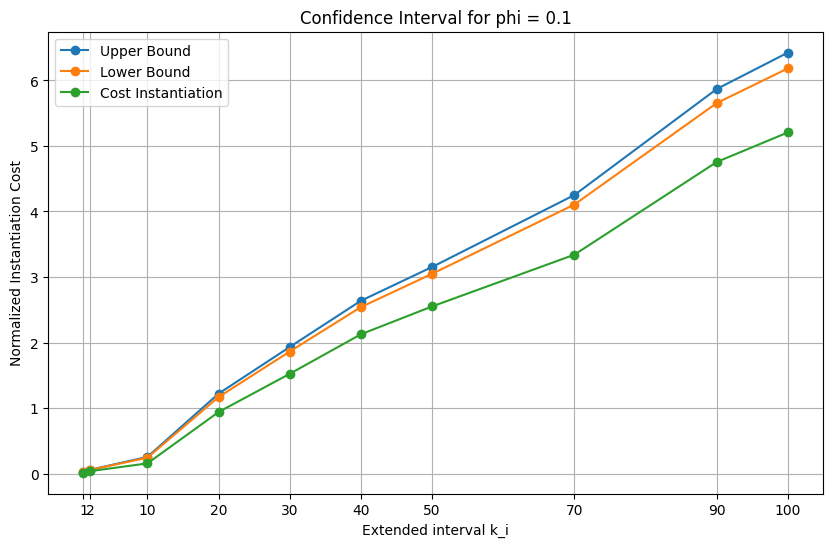

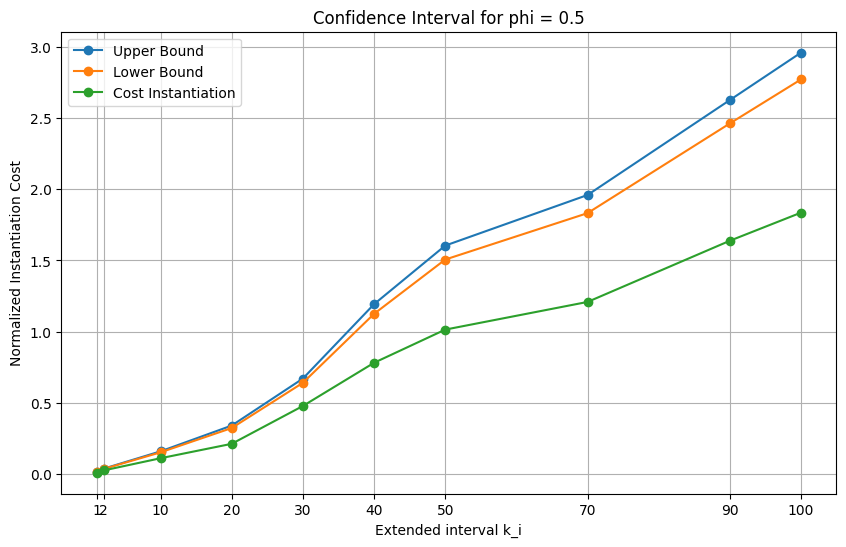

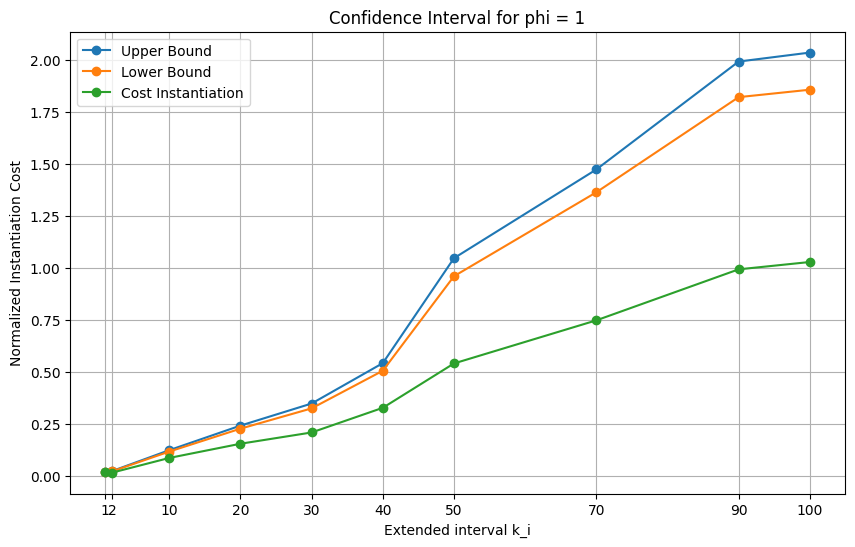

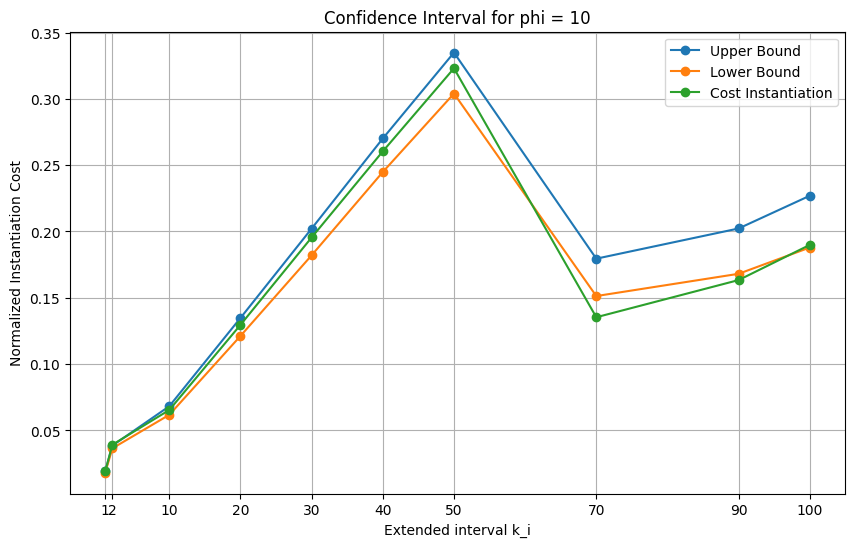

In [ ]:
cost_instantiation_list_
for i,phi in enumerate(PHIS):
    upper_list = []
    lower_list = []
    for j,eta in enumerate(ETAS):
        upper_cd_static, lower_cd_static = compute_confidence_interval(instantiation_costs[i,j,:])
        print(f'phi: {phi}, eta: {eta}, upper_cd_static: {upper_cd_static}, lower_cd_static: {lower_cd_static}')
        upper_list.append(upper_cd_static)
        lower_list.append(lower_cd_static)
    plt.figure(figsize=(10, 6))
    plt.plot(ETAS, upper_list, label='Upper Bound', marker='o')
    plt.plot(ETAS, lower_list, label='Lower Bound', marker='o')
    plt.plot(ETAS,cost_instantiation_list_[i,:], label='Cost Instantiation', marker='o')
    plt.title(f'Confidence Interval for phi = {phi}')
    plt.xlabel(r'Extended interval k_i')
    plt.ylabel('Normalized Instantiation Cost')
    plt.xticks(ETAS)
    plt.grid()
    plt.legend()

In [40]:
static_denorm_100 = np.zeros((static.shape))
shared_denorm_100 = np.zeros((shared.shape))
for i in range(B):
    static_denorm = static_scaler.inverse_transform(static[:,:,i]) # Static = block 1
    static_denorm_100[:,:,i]=static_denorm

    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared[:,i], axis=-1)) # Shared = block 2
    shared_denorm_100[:,i]=shared_denorm.reshape(-1)

    mae_forecasting[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
''' Normalize the data to be in the same scale as the real data.'''
shared_norm = shared_denorm_100 / 10e9 # Shared = block 2
static_norm = static_denorm_100 / 10e9 # Static = block 1
mae_norm = mae_forecasting / 10e9 # MAE = helper
output_norm = real_data[test_index_start:] / 10e9 # Real test data

diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

mae_norm_diff = mae_norm.shape[0] - diff
output_norm_diff = output_norm.shape[0] - diff
shared_norm_diff = shared_norm.shape[0] - diff
static_norm_diff = static_norm.shape[0] - diff

if mae_norm_diff != 0:
    mae_norm = mae_norm[mae_norm_diff:]
if output_norm_diff != 0:
    output_norm = output_norm[output_norm_diff:]
if shared_norm_diff != 0:
    shared_norm = shared_norm[shared_norm_diff:]
if static_norm_diff != 0:
    static_norm = static_norm[static_norm_diff:]


In [72]:
gamma = 2 # positive slope always fix

cplus_denorm = cplus_df_sel_np * 10e9 
static_denorm = static_norm * 10e9
shared_denorm = shared_norm * 10e9
output_denorm = output_norm * 10e9

# print(f'output_denorm.shape: {output_denorm.shape},\n cplus_denorm.shape: {cplus_denorm.shape},\n static_denorm.shape: {static_denorm.shape},\n shared_denorm.shape: {shared_denorm.shape}')

test_length=min(len(output_norm),len(shared_norm))
# 1734 is the minimum lenght among the test timeseries produced, i.e., block 1, block 2, helper.
# It may change city by city
#test_length = 1734

cplus_all=cplus_denorm.T[:test_length].sum(axis=1).reshape(-1,1) ## Sum of all the used shared capacity for all the services




cost_normalization_factor = (output_denorm[:test_length].max(axis=0)
                                - output_denorm[:test_length]).sum() * gamma

# eta = 2 # cost of instantiation
cost_instantiation_list=[]
for i in range(B):


    delta_i = np.zeros((test_length, num_services)) 
    rho_i = np.zeros((test_length, num_services))

    indexes_under = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) > 0)
    indexes_above = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) < 0)

    # Where the real load is below the allocated static, delta_i is equal to the real load.
    # In this case rho_i is equal to 0.

    for idx, element in enumerate(indexes_under[0]):
        delta_i[element, indexes_under[1][idx]] = output_denorm[element, indexes_under[1][idx]]

    # Where the real load is higher than the allocated static, delta_i is equal to the static denormalized.
    # In this case rho_i is equal to the difference between real load and static allocated.

    for idx, element in enumerate(indexes_above[0]):
        delta_i[element, indexes_above[1][idx]] = static_denorm[element, indexes_above[1][idx],i]
        rho_i[element, indexes_above[1][idx]] = (output_denorm[element, indexes_above[1][idx]]
                                                            - static_denorm[element, indexes_above[1][idx],i])

    delta_static = static_denorm[:test_length,:,i] - np.roll(static_denorm[:test_length,:,i], 1,axis=0)
    delta_static[0] = static_denorm[0,:,i]
    delta_shared = cplus_denorm.T[:test_length] - np.roll(cplus_denorm.T[:test_length], 1,axis=0)
    delta_shared[0] = cplus_denorm.T[0]

    cost_instantiation_static = np.zeros((test_length, num_services))
    cost_instantiation_static[np.where(delta_static > 0)] = eta * delta_i[np.where(delta_static > 0)]

    cost_instantiation_shared = np.zeros((test_length, num_services))

    cost_instantiation_shared[np.where(delta_shared > 0)] = eta * np.minimum(rho_i, cplus_denorm.T[:test_length])[np.where(delta_shared > 0)]

    cost_instantiation = (cost_instantiation_static.sum()
                        + cost_instantiation_shared.sum()) / cost_normalization_factor
    cost_instantiation_list.append(cost_instantiation)


In [74]:
cost_inst_array=np.array(cost_instantiation_list)

In [79]:
# cost_inst_array.std(axis=0)
cost_inst_array.mean(axis=0)

0.025115963144410416

In [68]:
indexes_under = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) > 0)
indexes_above = np.where((static_denorm[:test_length,:,i] - output_denorm[:test_length]) < 0)

In [ ]:
dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                            scale=cap_static.std(axis=-1))
dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                            scale=cap_shared.std(axis=-1))

ppf_2_static = .999
ppf_2_helper = .999

upper_cd_static = dist_cd.ppf(ppf_2_static) + 2*cap_static.std(axis=-1) # Can be changed. If set to 0.5 = mean




# upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
#     cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
# upper_cs_shared = dist_cs.ppf(ppf_2_helper) # Can be changed. If set to 0.5 = mean 
# upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
#     cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

In [61]:
cap_static.std(axis=-1).shape

(3577, 5)

In [62]:
dist_cd.std().shape

(3577, 5)

In [59]:
a=[1,2,3]
b=[1,2,3]

In [60]:
np.allclose(a,b)

True

In [58]:
## compare two arrays
np.allclose(upper_cd_static, cap_static.std(axis=-1), rtol=1e-05, atol=1e-08, equal_nan=False)

False

In [52]:
upper_cd_static.shape

(3577, 5)

In [41]:
cap_static.shape

(3577, 5, 100)

In [19]:
cap_static.shape

(3577, 5, 100)

In [55]:
std_cd_static.shape

(3577, 5)

In [47]:
std_cd_static.shape

(3577, 5)

In [42]:
dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                            scale=cap_static.std(axis=-1))
dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                            scale=cap_shared.std(axis=-1))

#compute confidence interval

mean_cd_static = dist_cd.mean()
mean_cs_shared = dist_cs.mean()
std_cd_static = dist_cd.std()
std_cs_shared = dist_cs.std()
#confidence interval
z = 1.96 # 95% confidence interval
upper_cd_static = mean_cd_static + z * std_cd_static
lower_cd_static = mean_cd_static - z * std_cd_static
upper_cs_shared = mean_cs_shared + z * std_cs_shared
lower_cs_shared = mean_cs_shared - z * std_cs_shared

In [46]:
lower_cd_static[0,0]

0.3220821987485153

In [44]:
upper_cd_static[0,0]

0.4755223293209808

In [23]:
np.nanmean(upper_cd_static)

0.3850575787305064

In [81]:
np.nanmean(lower_cs_shared)

0.0009367133775193753

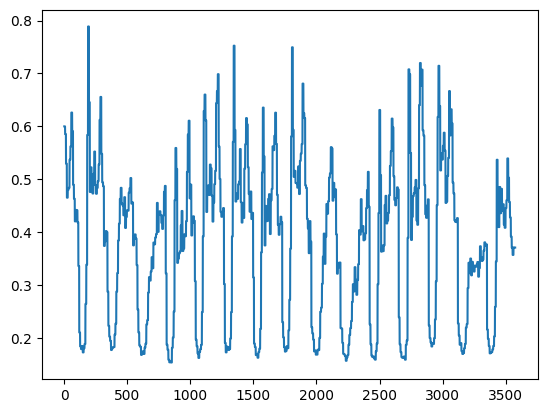

In [73]:
plt.plot(a)

In [72]:
np.mean(a)

nan

In [ ]:
upper_cd_static

In [46]:
cap_static.shape

(3577, 5, 100)

In [42]:
upper_cd_static.shape

(3577, 5)

In [54]:
df_costs_=df_costs(total_costs_list,cost_overprovisioning_list,cost_slas_list,cost_instantiation_list,cost_reconfiguration_list,sla_perc_list_index_list)

In [55]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_1_alpha_2_delay_7,0.275576,0.230267,0.024402,0.019844,0.001063
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_2_alpha_2_delay_21,0.407607,0.304883,0.076622,0.016927,0.009175
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_10_alpha_2_delay_21,0.476382,0.310918,0.071883,0.084917,0.008664
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_20_alpha_2_delay_33,0.684965,0.334008,0.187990,0.143919,0.019049
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_30_alpha_2_delay_35,0.657938,0.334845,0.117417,0.193430,0.012246
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_40_alpha_2_delay_48,0.930444,0.369126,0.245481,0.290152,0.025685
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_50_alpha_2_delay_85,1.083885,0.429594,0.104380,0.524859,0.025052
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_70_alpha_2_delay_85,1.275336,0.421903,0.116242,0.712044,0.025148
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_90_alpha_2_delay_85,1.523189,0.426840,0.103251,0.967919,0.025179
Paris_ppf_static_0.9_ppf_helper_0.7_phi_1_eta_100_alpha_2_delay_85,1.566558,0.433327,0.098297,1.011149,0.023786


In [43]:
df_costs_

,total_costs,cost_overprovisioning,cost_slas,cost_instantiation,cost_reconfiguration
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_1_alpha_2_delay_21,0.399804,0.286394,0.098060,0.010255,0.005095
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_2_alpha_2_delay_27,0.466802,0.321389,0.112310,0.024830,0.008273
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_10_alpha_2_delay_21,0.497799,0.278826,0.106189,0.107230,0.005554
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_20_alpha_2_delay_35,0.702951,0.316481,0.170994,0.206723,0.008753
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_30_alpha_2_delay_57,1.295437,0.417467,0.322104,0.531720,0.024146
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_40_alpha_2_delay_85,1.378669,0.407871,0.185495,0.765565,0.019739
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_50_alpha_2_delay_85,1.599303,0.423252,0.178171,0.978081,0.019800
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_70_alpha_2_delay_85,1.777390,0.403772,0.189759,1.166824,0.017035
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_90_alpha_2_delay_85,2.218429,0.398784,0.179881,1.621702,0.018062
Paris_ppf_static_0.9_ppf_helper_0.7_phi_0.5_eta_100_alpha_2_delay_85,2.387602,0.394337,0.197927,1.777142,0.018196


In [56]:
save_path

'Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05_LOWER_BOUND.csv'

In [64]:
old_value=pd.read_csv('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05.csv',index_col=0)
upper_bound = pd.read_csv('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05_UPPER_BOUND.csv',index_col=0)
lower_bound = pd.read_csv('/home/sergi_alcala/sergi_data/CLEAN_AZTEC_Extension/Benchmark/exp_smooth/Costs_Paris_AZTEC_EXT_RESULTS_OPT_KR_KI_ALLOC_Changed_phi_05_LOWER_BOUND.csv',index_col=0)

In [74]:
instantiation_upper = np.zeros((len(PHIS),len(ETAS)))
instantiation_lower = np.zeros((len(PHIS),len(ETAS)))
instantiation_old = np.zeros((len(PHIS),len(ETAS)))

for i,phi in enumerate(PHIS):
    for j,eta in enumerate(ETAS):
        delay=np.load (f'{ROOT_DIR}/{results_path}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
        instantiation_upper[i,j]=upper_bound.loc[f'Paris_ppf_static_0.9_ppf_helper_0.7_phi_{phi}_eta_{eta}_alpha_2_delay_{delay}','cost_instantiation']
        instantiation_lower[i,j]=lower_bound.loc[f'Paris_ppf_static_0.9_ppf_helper_0.7_phi_{phi}_eta_{eta}_alpha_2_delay_{delay}','cost_instantiation']
        instantiation_old[i,j]=old_value.loc[f'Paris_ppf_static_0.9_ppf_helper_0.7_phi_{phi}_eta_{eta}_alpha_2_delay_{delay}','cost_instantiation']

In [80]:
plt.style.use('/home/sergi_alcala/Matplotlib/style.mplstyle')

In [83]:
ETAS

[1, 2, 10, 20, 30, 40, 50, 70, 90, 100]

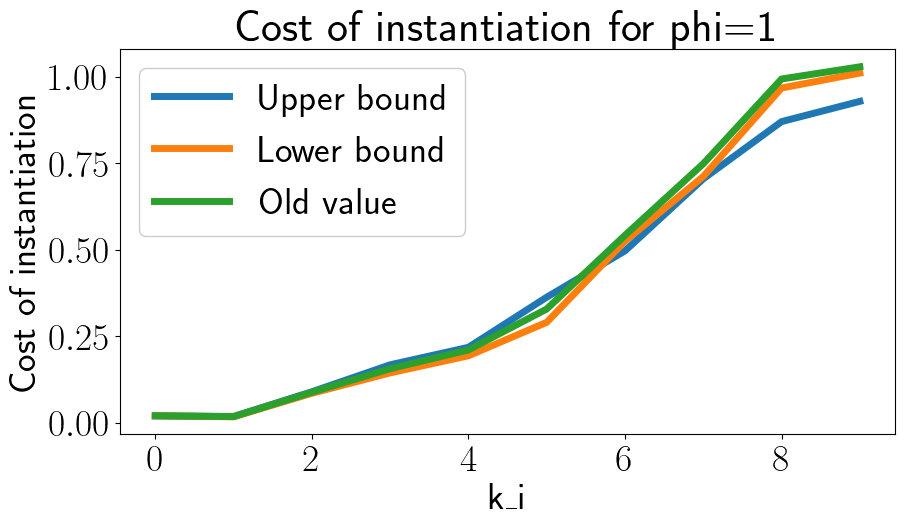

In [84]:
plt.figure(figsize=(10,5))
plt.plot(instantiation_upper[0,:],label='Upper bound')
plt.plot(instantiation_lower[0,:],label='Lower bound')
plt.plot(instantiation_old[0,:],label='Old value')
plt.title('Cost of instantiation for phi=1')
plt.xlabel(r'k_i')
plt.ylabel('Cost of instantiation')
plt.legend()

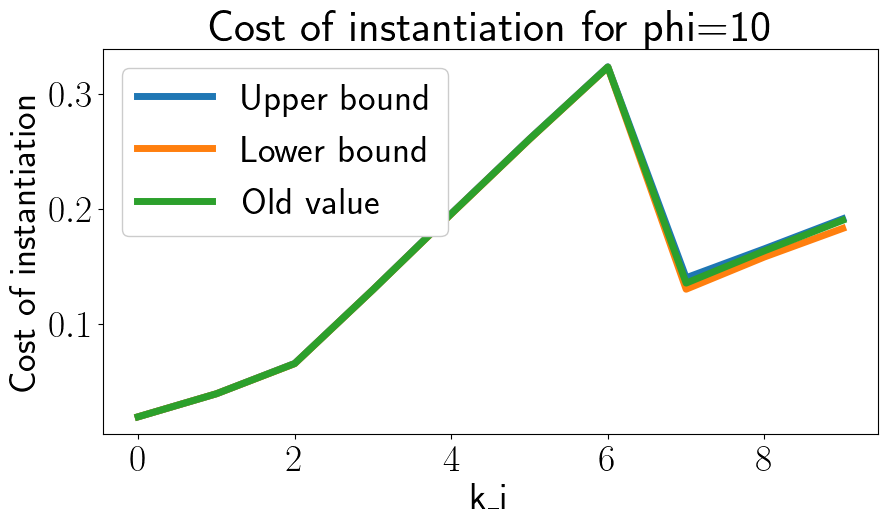

In [86]:
plt.figure(figsize=(10,5))
plt.plot(instantiation_upper[1,:],label='Upper bound')
plt.plot(instantiation_lower[1,:],label='Lower bound')
plt.plot(instantiation_old[1,:],label='Old value')
plt.title('Cost of instantiation for phi=10')
plt.xlabel(r'k_i')
plt.ylabel('Cost of instantiation')
plt.legend()

In [57]:
df_costs_.to_csv(f'{save_path}')

In [25]:
#check nan values in dataframe
df_costs_.isnull().sum()

total_costs              0
cost_overprovisioning    0
cost_slas                0
cost_instantiation       0
cost_reconfiguration     0
dtype: int64